In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
df = pd.read_csv('study.csv')
df.head()

,Attendance_Hours,Final_Marks
0,36.217808,58.997409
1,76.550001,71.598279
2,61.239576,72.520777
3,51.906094,69.005976
4,20.921305,53.259605


In [77]:
x = df.iloc[:,0:1].values
y = df.iloc[:,-1].values

x_mean = x.mean()
y_mean = y.mean()

x = (x_mean - x) / x.std()
y = (y_mean - y) / y.std()

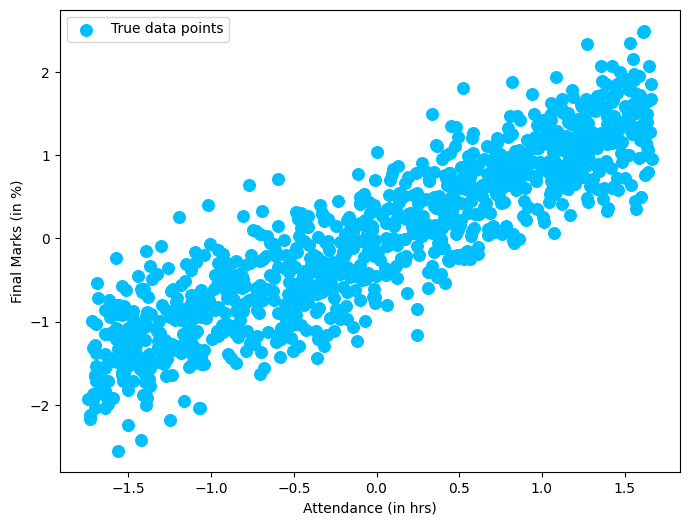

In [78]:
#  True data points
plt.figure(figsize = (8,6))
plt.scatter(x,y,color = 'deepskyblue', label = 'True data points', s = 70)
plt.xlabel('Attendance (in hrs)')
plt.ylabel('Final Marks (in %)')
plt.legend()
plt.show()

In [79]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 2)

In [80]:
# model training
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [81]:
y_pred = lr.predict(x_test)

In [82]:
lr.coef_ # slope(m)

array([0.89496667])

In [83]:
lr.intercept_ # intercept(b)

np.float64(-0.011222871151725908)

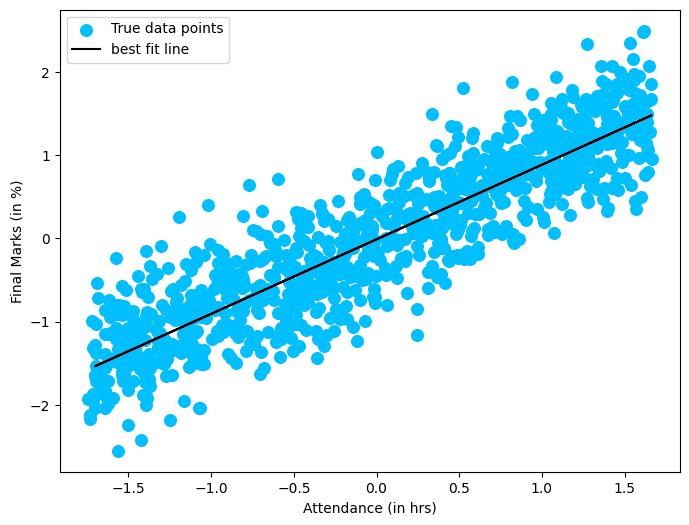

In [84]:
# best fit line
plt.figure(figsize = (8,6))
plt.scatter(x,y,color = 'deepskyblue', label = 'True data points', s = 70)
plt.plot(x_test, y_pred, color = 'k', label = 'best fit line')
plt.xlabel('Attendance (in hrs)')
plt.ylabel('Final Marks (in %)')
plt.legend()
plt.show()

In [85]:
# evaluatinon
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.8077930733821088

In [86]:
class GD:
  def __init__(self, learning_rate, epochs):
    self.m = 0.0 # Initializing m to a small value
    self.b = 0.0 # Initializing b to a small value
    self.n = learning_rate
    self.epochs = epochs
    self.loss_history = [] # Initialize loss_history as an instance variable

  def fit(self, x_train, y_train):
    N = x_train.shape[0]
    for i in range(self.epochs):
      y_pred = self.m * x_train.ravel() + self.b
      loss_slope_b = (-2/N) * np.sum(y_train - y_pred)
      loss_slope_m = (-2/N) * np.sum((y_train - y_pred) * x_train.ravel())

      self.b -= (loss_slope_b * self.n)
      self.m -= (loss_slope_m * self.n)

      mse = np.mean((y_pred - y_train)**2)
      self.loss_history.append(mse) # Append to instance variable

      print(f'epoch {i} | loss: {mse} ')
    print('\n')
    print('final parameters ✅')
    print('m = ',self.m)
    print('b = ',self.b)

  def predict(self, x_test):
    return self.m * x_test + self.b

In [89]:
gd = GD(learning_rate=0.1, epochs=100) # Reduced learning rate
gd.fit(x_train,y_train)

epoch 0 | loss: 0.9946356750128473 
epoch 1 | loss: 0.708118890965454 
epoch 2 | loss: 0.5244363953574777 
epoch 3 | loss: 0.4066786479057235 
epoch 4 | loss: 0.33118416485327634 
epoch 5 | loss: 0.28278421158935224 
epoch 6 | loss: 0.25175443402841025 
epoch 7 | loss: 0.23186069719588828 
epoch 8 | loss: 0.21910635533231138 
epoch 9 | loss: 0.2109291724669854 
epoch 10 | loss: 0.20568649270758527 
epoch 11 | loss: 0.20232519555768186 
epoch 12 | loss: 0.20017011041389307 
epoch 13 | loss: 0.1987883717817926 
epoch 14 | loss: 0.19790245832000117 
epoch 15 | loss: 0.1973344422434731 
epoch 16 | loss: 0.19697024733285978 
epoch 17 | loss: 0.19673673435207548 
epoch 18 | loss: 0.1965870101231608 
epoch 19 | loss: 0.19649100884018034 
epoch 20 | loss: 0.1964294534801959 
epoch 21 | loss: 0.1963899842557972 
epoch 22 | loss: 0.19636467641001676 
epoch 23 | loss: 0.19634844876015545 
epoch 24 | loss: 0.1963380433325598 
epoch 25 | loss: 0.19633137114754662 
epoch 26 | loss: 0.196327092760541

In [88]:
lr.coef_

array([0.89496667])

In [90]:
lr.intercept_

np.float64(-0.011222871151725908)

In [95]:
y_pred_gd = gd.predict(x_test)
r2_Score_gd = r2_score(y_test, y_pred_gd)
r2_Score_gd, r2

(0.8077930733824272, 0.8077930733821088)

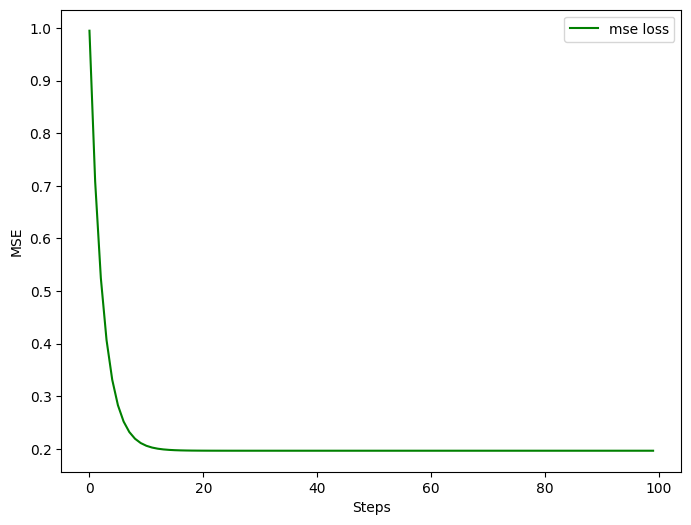

In [102]:
# loss curve
plt.figure(figsize=(8,6))
plt.plot(range(gd.epochs), gd.loss_history, color = 'green', label = 'mse loss')
plt.ylabel('MSE')
plt.xlabel('Steps')
plt.legend()
plt.show()